In [1]:
import copy
import random
import joblib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

In [4]:
SEED = 42
def set_seed(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed()

# Main
BATCH_SIZE = 16
MAX_EPOCHS = 80
PATIENCE = 8
VAL_FRACTION = 0.10 # leave out 10% of training for validation -> will make lower when we import 2018 - 2021

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print(device)


mps


### Load Data

In [5]:
data = pd.read_csv("../data/Cleaned_data2022-2025.csv")
data = data.sort_values(["Year", "Circuit", "Driver", "LapNumber"]).reset_index(drop=True)
print(data.shape)
data.head()

(89164, 21)


,Driver,Circuit,Year,LapNumber,LapsRemaining,Compound,TyreLife,TrackStatusSimple,Position,AirTemp,...,Pressure,TrackTemp,WindDirection,WindSpeed,Stint,Rainfall,InLap,OutLap,LapTimeSeconds,TargetLapTime
0,ALB,Austin,2022,1.0,55.0,MEDIUM,1.0,2,9.0,28.9,...,991.5,34.6,92,3.9,1.0,False,0,0,109.136,105.350
1,ALB,Austin,2022,2.0,54.0,MEDIUM,2.0,1,10.0,28.9,...,991.7,34.6,112,4.3,1.0,False,0,0,105.350,104.781
2,ALB,Austin,2022,3.0,53.0,MEDIUM,3.0,1,10.0,28.9,...,991.5,34.7,105,4.5,1.0,False,0,0,104.781,105.143
3,ALB,Austin,2022,4.0,52.0,MEDIUM,4.0,1,11.0,29.0,...,991.5,34.7,106,5.8,1.0,False,0,0,105.143,106.242
4,ALB,Austin,2022,5.0,51.0,MEDIUM,5.0,1,12.0,29.0,...,991.5,34.6,103,7.0,1.0,False,0,0,106.242,104.688


### Features

In [6]:
cat_features = [
    'Driver',
    'Circuit',
    'Year',
    'Compound',
    'TrackStatusSimple',
    'Rainfall',
]

num_features = [
    'LapNumber',
    'LapsRemaining',
    'TyreLife',
    'AirTemp',
    'Humidity',
    'Pressure',
    'TrackTemp',
    'WindDirection',
    'WindSpeed',
    'LapTimeSeconds',
    'Position',
    'Stint',
]
binary_features = [
    'InLap',
    'OutLap'
]
TARGET = "TargetLapTime"

In [12]:
def make_preprocessor():
    return ColumnTransformer(
        transformers = [
            ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),cat_features),
            ("num",StandardScaler(),num_features),
            ("binary","passthrough",binary_features)
        ],
        sparse_threshold=0
    )

### Train / Validation / Test split

In [13]:
test_races = [
    "Shanghai",
    "Silverstone",
    "Spa-Francorchamps",
    "Spielberg",
    "Suzuka",
    "São Paulo",
    "Yas Island",
    "Zandvoort"
]

In [14]:
test_mask = (
    (data['Circuit'].isin(test_races)) &
    (data['Year'] == 2025)
)

In [16]:
trainval_data = data[~test_mask].copy()
test_data = data[test_mask].copy()

#### Validation


In [17]:
races = trainval_data[["Year","Circuit"]].drop_duplicates().reset_index(drop=True)

In [19]:
n_val = max(1, int(round(VAL_FRACTION * len(races))))
rng = np.random.default_rng(SEED)
val_races = races.iloc[rng.choice(len(races),size=n_val,replace=False)]
val_key = set(zip(val_races["Year"],val_races["Circuit"]))
is_val = np.array([k in val_key for k in zip(trainval_data["Year"], trainval_data["Circuit"])])

In [20]:
train_data = trainval_data[~is_val].copy()
val_data = trainval_data[is_val].copy()
print(f"train {len(train_data)} rows val {len(val_data)} rows test {len(test_data)} rows")


train 72070 rows val 8532 rows test 8562 rows


In [21]:
preprocessor = make_preprocessor()
preprocessor.fit(train_data.drop(columns=[TARGET]))
input_size = len(preprocessor.get_feature_names_out())

In [22]:
input_size

86

### Preprocessing

In [23]:
X_train = preprocessor.transform(train_data.drop(columns=TARGET)).astype(np.float32)
X_val = preprocessor.transform(val_data.drop(columns=TARGET)).astype(np.float32)
X_test = preprocessor.transform(test_data.drop(columns=TARGET)).astype(np.float32)

def delta_target(df):
    return (df[TARGET] - df["LapTimeSeconds"]).to_numpy(dtype=np.float32)
    
y_train = delta_target(train_data)
y_val = delta_target(val_data)
y_test = delta_target(test_data)


### Tensorfying

In [27]:
X_train_tensor, X_val_tensor, X_test_tensor = map(torch.from_numpy, (X_train, X_val, X_test))

y_train_tensor = torch.from_numpy(y_train).unsqueeze(1)
y_val_tensor = torch.from_numpy(y_val).unsqueeze(1)


In [28]:
input_size = X_train.shape[1]
input_size

86

### Dataset and Dataloader

In [31]:
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

In [34]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  #unlike lstm rows are independent wooo
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [35]:
val_loader

### Model

In [62]:
class LapTimeNN(nn.Module):
    def __init__(self, input_size, dropout=0.1):
        super().__init__()

        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x


In [63]:
def init_model(input_size, lr):

    model = LapTimeNN(input_size)

    optimizer = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=1e-5)

    loss_function = nn.HuberLoss(delta=1.0)

    return model, optimizer, loss_function

### Training

In [64]:
def run_epoch(model,loader,optimizer=None, loss_function=None):
    
    training = optimizer is not None
    
    model.train(training)
    
    total, count = 0.0, 0.0
    
    with torch.set_grad_enabled(training):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device) # moving to gpu

            loss = loss_function(model(X_batch), y_batch)
            
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            total += loss.item() * len(X_batch)   # last batch is smaller
    return total / len(loader.dataset)


In [67]:
def train_model(train_loader,val_loader,input_size,max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=1e-3):
    history = {"train": [], "val": []}
    model, optimizer, loss_function = init_model(input_size,lr)

    model = model.to(device)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3) # lowers lr when traiing stops improving, patience is how many epochs you wait


    best_val, best_state, bad_epochs = float("inf"), None, 0

    for epoch in range(1,max_epochs + 1):
        
        tr = run_epoch(model, train_loader, optimizer, loss_function)
        va = run_epoch(model, val_loader, loss_function=loss_function)

        scheduler.step(va)
        history["train"].append(tr)
        history["val"].append(va)

        # early stopping
        if va < best_val - 1e-4:
            best_val, bad_epochs = va, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            bad_epochs += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f"epoch {epoch:3d} | train {tr:.4f} | val {va:.4f}")
        if bad_epochs >= patience:
            print(f"early stop at epoch {epoch} (best val {best_val:.4f})")
            break

    model.load_state_dict(best_state)
    return model, history



In [68]:
model, history = train_model(train_loader, val_loader, input_size)

epoch   1 | train 2.1929 | val 2.1723
epoch   5 | train 1.7130 | val 2.3155
early stop at epoch 9 (best val 2.1723)


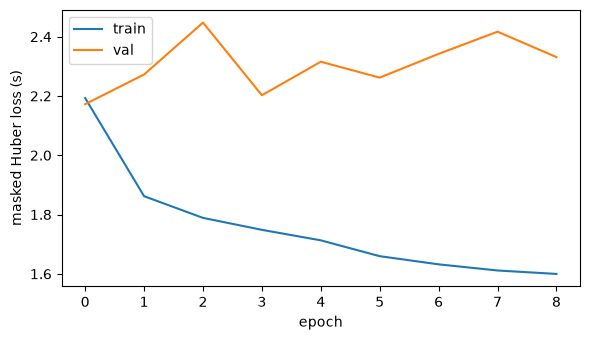

In [69]:
plt.figure(figsize=(6, 3.5))
plt.plot(history["train"], label="train")
plt.plot(history["val"], label="val")
plt.xlabel("epoch"); plt.ylabel("masked Huber loss (s)"); plt.legend(); plt.tight_layout()
plt.show()

### Evaluation

In [70]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, median_absolute_error

In [75]:
@torch.no_grad()
def predict_laptimes(model, X_tensor, cur_laptimes, batch_size=4096):
    model.eval()
    out = [model(X_tensor[i:i + batch_size].to(device)).cpu() for i in range(0, len(X_tensor), batch_size)]
    delta = torch.cat(out).squeeze(1).numpy()
    return np.asarray(cur_laptimes) + delta

def metrics(pred, actual, name):
    err = np.asarray(pred) - np.asarray(actual)
    return {"model": name, "MAE": np.abs(err).mean(),
            "MedAE": np.median(np.abs(err)), "RMSE": np.sqrt((err ** 2).mean())}


In [83]:
pred = predict_laptimes(model,X_val_tensor,val_data["LapTimeSeconds"])
actual = val_data[TARGET].to_numpy()
pd.DataFrame(
    [metrics(pred, actual, "ANN")]
).set_index("model").round(3)

,MAE,MedAE,RMSE
model,,,
ANN,2.476,0.377,6.686


In [85]:
print("Test Races")

# per-circuit MAE on test
test_preds = predict_laptimes(model, X_test_tensor, test_data["LapTimeSeconds"])
test_data = test_data.copy()
test_data["Prediction"] = test_preds
test_data["AbsError"] = np.abs(
    test_data["Prediction"] - test_data[TARGET]
)

per_circuit = test_data.groupby("Circuit")["AbsError"].mean()

pd.DataFrame({"ANN MAE": per_circuit}).round(3)

Test Races


,ANN MAE
Circuit,
Shanghai,1.079
Silverstone,7.535
Spa-Francorchamps,2.272
Spielberg,1.314
Suzuka,0.704
São Paulo,3.329
Yas Island,0.459
Zandvoort,4.482


In [90]:
print(test_data["Circuit"].unique())
print(test_data["Year"].unique())

['Shanghai' 'Silverstone' 'Spa-Francorchamps' 'Spielberg' 'Suzuka'
 'São Paulo' 'Yas Island' 'Zandvoort']
[2025]


In [102]:
# SHOW
def plot_laptimes(race, driver):
    mask = (
        (test_data["Circuit"].str.lower() == race.lower()) &
        (test_data["Driver"].str.lower() == driver.lower())
    )

    positions = np.where(mask.to_numpy())[0]

    if len(positions) == 0:
        print(f"0 datra for {driver} at {race}")
        return

    df = test_data.iloc[positions].copy()
    X = X_test_tensor[positions]

    p = predict_laptimes(model, X, df["LapTimeSeconds"])

    # Sort by lap number
    order = np.argsort(df["LapNumber"].to_numpy())
    df = df.iloc[order]
    p = p[order]

    plt.figure(figsize=(10, 8))
    plt.plot(df["LapNumber"], df[TARGET], label="Actual")
    plt.plot(df["LapNumber"], p, label="ANN prediction")

    plt.title(f"{race} {df['Year'].iloc[0]} - {driver}")
    plt.xlabel("Lap index")
    plt.ylabel("Lap time (s)")
    plt.legend()
    plt.tight_layout()
    plt.show()

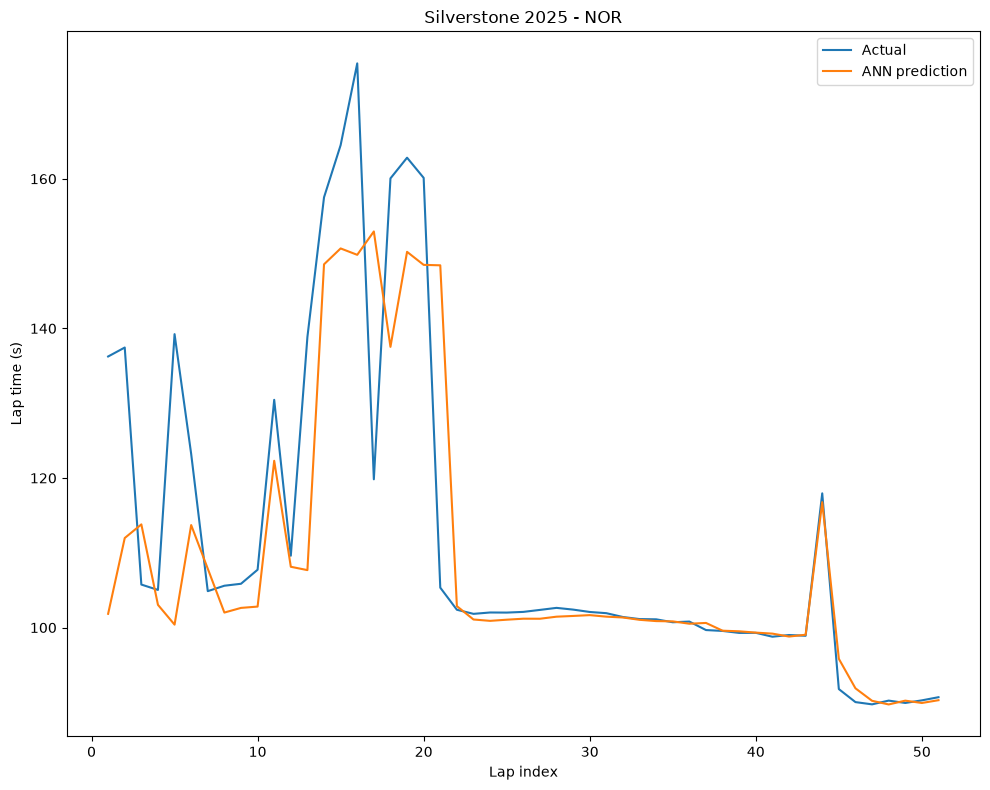

In [103]:
plot_laptimes("Silverstone","NOR")